In [1]:
import numpy as np
import subprocess
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import os

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print(f"Setting root of the project to: {root}")

def alleleFrequency(base, allele_count):
    # Allele count format: [A : T : C : G : N : del]
    base_dict = {
        'A': 0,
        'T': 1,
        'C': 2,
        'G': 3,
        'N': 4,   # unused
        'del': 5  # unsued, both defined to be explicit
    }
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq, total
    
def readAlleleFrequencyData(file_path="../data/chromosome_2L.sync"):
    columns = [
        'chromosome',
        'position',
        'base',
        'Dsim_Fl_Base_1',
        'Dsim_Fl_Hot_F10_1',
        'Dsim_Fl_Hot_F20_1', 
        'Dsim_Fl_Hot_F30_1',
        'Dsim_Fl_Hot_F40_1', 
        'Dsim_Fl_Hot_F50_1', 
        'Dsim_Fl_Hot_F60_1'
    ]

    df = pd.read_csv(
        filepath_or_buffer=file_path,
        sep='\t', # tab-separated values
        names=columns,
        usecols=columns,
        header=None # no headers provided
    )

    rename_dict = {
        'Dsim_Fl_Base_1':    'gen_0',
        'Dsim_Fl_Hot_F10_1': 'gen_10',
        'Dsim_Fl_Hot_F20_1': 'gen_20',
        'Dsim_Fl_Hot_F30_1': 'gen_30',
        'Dsim_Fl_Hot_F40_1': 'gen_40',
        'Dsim_Fl_Hot_F50_1': 'gen_50',
        'Dsim_Fl_Hot_F60_1': 'gen_60'
    }

    # Rename the columns (inplace=True modifies the original DataFrame)
    df.drop(columns=['chromosome'], inplace=True)
    df.rename(columns=rename_dict, inplace=True)

    for column in ['gen_0','gen_10','gen_20','gen_30','gen_40','gen_50','gen_60']:
        df[[column, f'total_{column}']] = [
            alleleFrequency(b, c) 
            for b, c in zip(df['base'], df[column])
        ]
        
    for generation in [10,20,30,40,50,60]:
        prev_generation = generation - 10
        df[f'delta_{generation}'] = df[f'gen_{generation}'] - df[f'gen_{prev_generation}']

    return df

def readSamples():
    dir_path = "../slim/outputs/"
    file_paths = []
    for filename in os.listdir(dir_path):
        full_path = os.path.join(dir_path, filename)
        if os.path.isfile(full_path):
            file_paths.append(full_path)

    df_list = []
    for file_path in file_paths:
        tmp = pd.read_csv(file_path)
        df_list.append(tmp)

    df = pd.concat(df_list, ignore_index=True)
    df.drop(inplace=True, columns=['Unnamed: 0'])
    return df

sim = readSamples()
print(sim.head())

df = readAlleleFrequencyData()
print(df.head())

Setting root of the project to: /home/kv/education/predicting_DFE
   position     sim_10     sim_20    sim_30     sim_40     sim_50     sim_60  \
0  10194546  125.66925  195.12125  178.5000  175.37625  159.12750  149.26275   
1  10194549  135.48500  139.52125  139.6875  163.13625  117.78375  115.54650   
2  10194552  105.48475  127.88000  195.5625  132.91875  122.92875  187.53525   
3  10194557    5.39175    2.43250    0.0000    4.39875    4.04250    3.09825   
4  10194670  342.58350  461.82750  479.4375  466.65000  482.52750  469.65825   

   simdelta_20  simdelta_30  simdelta_40  simdelta_50  simdelta_60  alpha  \
0     69.45200    -16.62125     -3.12375    -16.24875     -9.86475  2.975   
1      4.03625      0.16625     23.44875    -45.35250     -2.23725  2.975   
2     22.39525     67.68250    -62.64375     -9.99000     64.60650  2.975   
3     -2.95925     -2.43250      4.39875     -0.35625     -0.94425  2.975   
4    119.24400     17.61000    -12.78750     15.87750    -12.86925  

In [2]:
df['avg_delta'] = (df['delta_10'] + df['delta_20'] + df['delta_30'] + df['delta_40'] + df['delta_50'] + df['delta_60']) / 6
df['avg_freq'] = (df['gen_0'] + df['gen_10'] + df['gen_20'] + df['gen_30'] + df['gen_40'] + df['gen_50'] + df['gen_60']) / 7
df['s_est'] = (df['avg_delta'] / (df['avg_freq'] * (1 - df['avg_freq'] - pow(df['avg_delta'], 2))))
df['phi_est'] = df['s_est'] + 1
df.head()

,position,base,gen_0,gen_10,gen_20,gen_30,gen_40,gen_50,gen_60,total_gen_0,...,delta_10,delta_20,delta_30,delta_40,delta_50,delta_60,avg_delta,avg_freq,s_est,phi_est
0,59,T,0.157895,0.227273,0.280702,0.238095,0.229167,0.216495,0.204819,76.0,...,0.069378,0.053429,-0.042607,-0.008929,-0.012672,-0.011676,0.007821,0.222064,0.045275,1.045275
1,62,A,0.156627,0.233333,0.262295,0.247191,0.222930,0.226415,0.195402,83.0,...,0.076707,0.028962,-0.015104,-0.024261,0.003485,-0.031013,0.006463,0.220599,0.037590,1.037590
2,153,A,0.200000,0.194030,0.194737,0.261682,0.205882,0.176923,0.218750,140.0,...,-0.005970,0.000707,0.066945,-0.055800,-0.028959,0.041827,0.003125,0.207429,0.019008,1.019008
3,207,G,0.109589,0.093750,0.086705,0.083333,0.093333,0.053030,0.124031,146.0,...,-0.015839,-0.007045,-0.003372,0.010000,-0.040303,0.071001,0.002407,0.091967,0.028823,1.028823
4,219,T,0.051948,0.071429,0.062500,0.063291,0.059055,0.083333,0.100000,154.0,...,0.019481,-0.008929,0.000791,-0.004236,0.024278,0.016667,0.008009,0.070222,0.122669,1.122669


In [3]:
sim

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
0,10194546,125.66925,195.12125,178.5000,175.37625,159.12750,149.26275,69.45200,-16.62125,-3.12375,-16.24875,-9.86475,2.975000,2.925000
1,10194549,135.48500,139.52125,139.6875,163.13625,117.78375,115.54650,4.03625,0.16625,23.44875,-45.35250,-2.23725,2.975000,2.925000
2,10194552,105.48475,127.88000,195.5625,132.91875,122.92875,187.53525,22.39525,67.68250,-62.64375,-9.99000,64.60650,2.975000,2.925000
3,10194557,5.39175,2.43250,0.0000,4.39875,4.04250,3.09825,-2.95925,-2.43250,4.39875,-0.35625,-0.94425,2.975000,2.925000
4,10194670,342.58350,461.82750,479.4375,466.65000,482.52750,469.65825,119.24400,17.61000,-12.78750,15.87750,-12.86925,2.975000,2.925000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529995,12509860,38.64350,34.79000,36.6240,61.50025,68.98375,86.17450,-3.85350,1.83400,24.87625,7.48350,17.19075,1.002778,1.013889
2529996,12509995,3.09575,0.00000,5.3760,6.52575,12.11000,0.00000,-3.09575,5.37600,1.14975,5.58425,-12.11000,1.002778,1.013889
2529997,12510001,24.23225,23.99800,44.0160,55.17225,48.87250,35.94325,-0.23425,20.01800,11.15625,-6.29975,-12.92925,1.002778,1.013889
2529998,12510011,19.32175,32.94400,49.0560,37.77025,40.43875,47.99875,13.62225,16.11200,-11.28575,2.66850,7.56000,1.002778,1.013889


<Axes: xlabel='sim_20', ylabel='Count'>

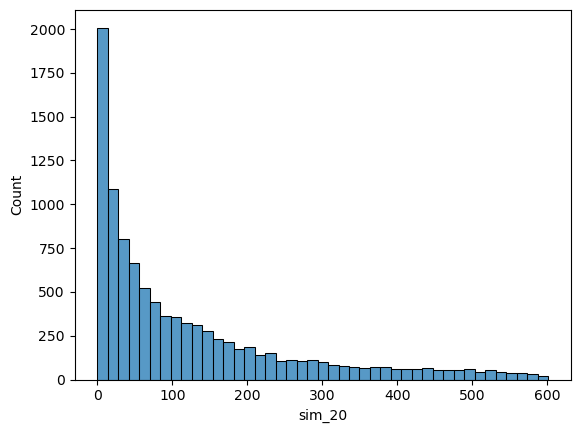

In [79]:
sns.histplot(sim.sim_20)

In [3]:
from scipy.stats import gamma

alpha_fit, loc_fit, scale_fit = gamma.fit(df.phi_est[df.phi_est >= 0], floc=0)
beta_fit = 1 / scale_fit

print(f"alpha: {alpha_fit}, beta: {beta_fit}")

expected = alpha_fit / beta_fit
variance = alpha_fit / pow(beta_fit, 2)

print(f"expected: {expected}, variance: {variance}")

alpha: 80.42114436027808, beta: 80.43147086045346
expected: 0.9998716111981428, variance: 0.012431348084295194


<Axes: xlabel='phi_est', ylabel='Count'>

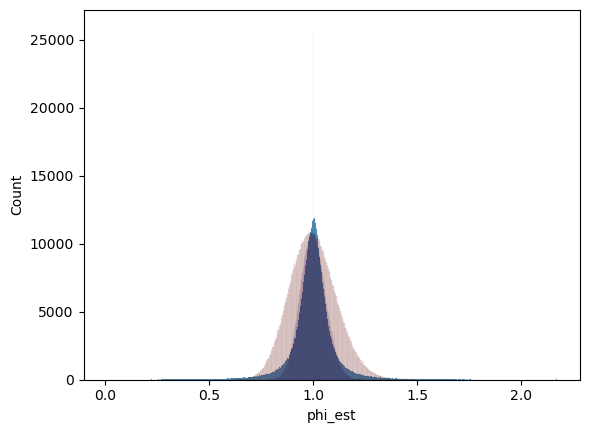

In [4]:
sns.histplot(x=df.phi_est[df.phi_est > 0])

fake_gamma = gamma.rvs(a = alpha_fit, scale = 1/beta_fit, size=1_000_000)
fake_gamma2 = gamma.rvs(a = alpha_fit+200, scale = 1/(beta_fit + 200), size=1_000_000)

sns.histplot(x=fake_gamma, color='red', alpha=.1)
sns.histplot(x=fake_gamma2, color='purple', alpha=.1)

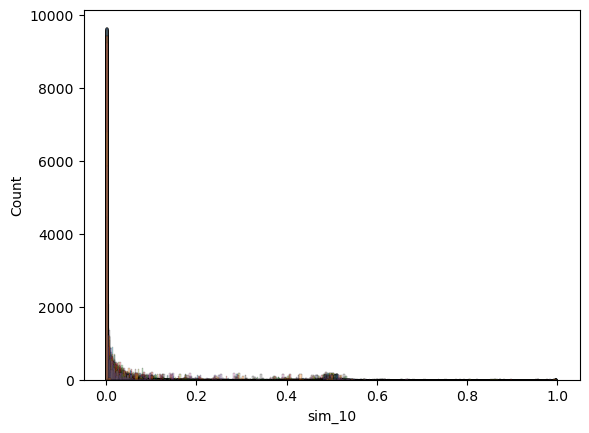

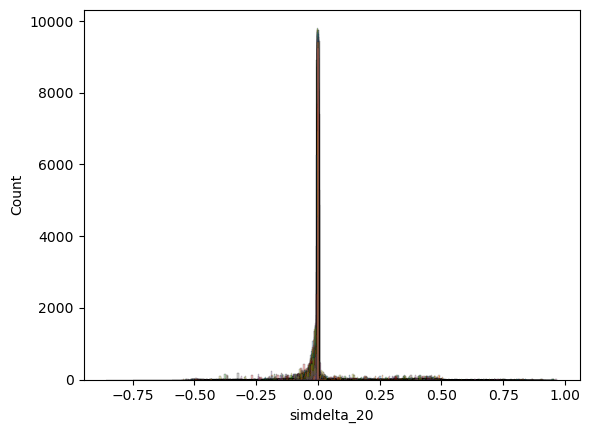

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
1,10194549,0.0885,0.1155,0.2745,0.4380,0.4860,0.4665,0.0270,0.1590,0.1635,0.0480,-0.0195,3.992993,3.992993
73,10214789,0.0885,0.1145,0.2750,0.4360,0.4910,0.4960,0.0260,0.1605,0.1610,0.0550,0.0050,3.992993,3.992993
76,10215665,0.2805,0.2625,0.3040,0.1655,0.1090,0.3205,-0.0180,0.0415,-0.1385,-0.0565,0.2115,3.992993,3.992993
79,10215832,0.0885,0.1145,0.2750,0.4360,0.4905,0.4960,0.0260,0.1605,0.1610,0.0545,0.0055,3.992993,3.992993
111,10227096,0.2875,0.2615,0.3045,0.1655,0.1090,0.3205,-0.0260,0.0430,-0.1390,-0.0565,0.2115,3.992993,3.992993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199829,12484678,0.0085,0.5085,0.4890,0.5120,0.4960,0.5255,0.5000,-0.0195,0.0230,-0.0160,0.0295,10.577578,10.876877
1199833,12485004,0.2390,0.1045,0.0625,0.0135,0.0070,0.0160,-0.1345,-0.0420,-0.0490,-0.0065,0.0090,10.577578,10.876877
1199898,12494208,0.2395,0.3870,0.4485,0.4750,0.5000,0.9675,0.1475,0.0615,0.0265,0.0250,0.4675,10.577578,10.876877
1199944,12501246,0.0170,0.5085,0.4875,0.5115,0.4930,0.0165,0.4915,-0.0210,0.0240,-0.0185,-0.4765,10.577578,10.876877


In [5]:
y_alpha, y_beta = sim[['alpha', 'beta']]

for alpha in sim.alpha.unique():
    for beta in sim.beta.unique():
        sns.histplot(sim.sim_10[(sim.alpha == alpha) & (sim.beta == beta)], alpha=.3)
plt.show()


for alpha in sim.alpha.unique():
    for beta in sim.beta.unique():
        sns.histplot(sim.simdelta_20[(sim.alpha == alpha) & (sim.beta == beta)], alpha=.3)
plt.show()


sim[sim.sim_60 != 0]

In [100]:
import pandas as pd

# simL = sim[['position', 'alpha', 'beta', 'sim_10', 'sim_20', 'sim_30', 'sim_40', 'sim_50', 'sim_60']].copy()
simL = sim[['position', 'alpha', 'beta', 'simdelta_20', 'simdelta_30', 'simdelta_40', 'simdelta_50', 'simdelta_60']].copy()

# 1. Sort and rank the positions from 1 to 10,000 within each alpha/beta group
simL = simL.sort_values(['alpha', 'beta', 'position'])
simL['norm_position'] = simL.groupby(['alpha', 'beta']).cumcount() + 1

# 2. Melt the dataframe
id_vars = ['norm_position', 'alpha', 'beta']
# value_vars = ['sim_10', 'sim_20', 'sim_30', 'sim_40', 'sim_50', 'sim_60']
value_vars = ['simdelta_20', 'simdelta_30', 'simdelta_40', 'simdelta_50', 'simdelta_60']

df_melted = simL.melt(id_vars=id_vars, value_vars=value_vars, 
                       var_name='time', value_name='diff')

# 3. Clean up the time string (e.g., 'sim_10' -> '1')
# df_melted['time'] = df_melted['time'].str.replace("sim_", "").str.replace("0", "").astype(int)
df_melted['time'] = df_melted['time'].str.replace("simdelta_", "").str.replace("0", "").astype(int) - 1

# 4. Generate the wide column names (p1_t1 ... p10000_t6)
df_melted['col_name'] = 'p' + df_melted['norm_position'].astype(str) + '_t' + df_melted['time'].astype(str)

# 5. Pivot using a clean list of strings for the MultiIndex
df_wide = df_melted.pivot(index=['alpha', 'beta'], columns='col_name', values='diff')

# Optional: Bring alpha and beta back as regular columns instead of index levels
df_wide = df_wide.reset_index()

In [101]:
df_wide

col_name,alpha,beta,p10000_t1,p10000_t2,p10000_t3,p10000_t4,p10000_t5,p1000_t1,p1000_t2,p1000_t3,...,p99_t1,p99_t2,p99_t3,p99_t4,p99_t5,p9_t1,p9_t2,p9_t3,p9_t4,p9_t5
0,1.000000,1.000000,0.0000,0.0,0.0,0.0,0.0,-0.042,-0.0015,0.0,...,-0.0020,0.0,0.0,0.0,0.0,-0.0150,0.0,0.0,0.0,0.0
1,1.299299,1.299299,-0.0090,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,0.0000,0.0,0.0,0.0,0.0,-0.0320,0.0,0.0,0.0,0.0
2,1.598599,1.598599,-0.0095,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,-0.0210,0.0,0.0,0.0,0.0,-0.0005,0.0,0.0,0.0,0.0
3,1.897898,1.897898,0.0000,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
4,2.197197,2.197197,0.0000,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,14.169169,14.468468,0.0000,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,-0.0015,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
116,14.169169,14.767768,0.0000,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
117,14.468468,13.869870,0.0000,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0
118,14.468468,14.169169,0.0000,0.0,0.0,0.0,0.0,0.000,0.0000,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0


In [107]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split

# ==========================================
# 1. DATA PREPARATION FUNCTION
# ==========================================
def process_and_prepare_tensors(df_wide):
    print("Extracting targets and features...")
    targets = df_wide[['alpha', 'beta']].values
    
    # Isolate and sort features to ensure absolute alignment: p1_t1...p1_t6, p2_t1...
    feature_cols = [c for c in df_wide.columns if c.startswith('p')]
    feature_cols.sort(key=lambda x: (int(x.split('_')[0][1:]), int(x.split('_')[1][1:])))
    
    # Extract flat matrix
    flat_matrix = df_wide[feature_cols].values 
    num_samples = len(df_wide)
    
    print(f"Reshaping matrix for 3D CNN input: {num_samples} samples...")
    # Reshape to (Num_Samples, 10000 positions, 6 time steps)
    # reshaped = flat_matrix.reshape(num_samples, 10000, 6)
    reshaped = flat_matrix.reshape(num_samples, 10000, 5)
    
    # Permute axes to PyTorch Conv1D format: (Num_Samples, Channels=6, Length=10000)
    X_tensor = torch.tensor(reshaped, dtype=torch.float).permute(0, 2, 1)
    y_tensor = torch.tensor(targets, dtype=torch.float)
    
    return TensorDataset(X_tensor, y_tensor)


# ==========================================
# 2. DEFINE THE 1D CNN MODEL
# ==========================================
class AlphaBetaCNN1D(nn.Module):
    def __init__(self):
        super(AlphaBetaCNN1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=5, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)
        
        self.pool = nn.MaxPool1d(kernel_size=4, stride=4)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# ==========================================
# 3. MAIN RUNTIME EXECUTION
# ==========================================
if __name__ == "__main__":
    # --- STEP A: Load your wide DataFrame ---
    # Replace this placeholder with how you access your processed `df_wide` from earlier
    # e.g., df_wide = pd.read_csv('your_wide_data.csv')
    print("Loading data...")
    
    # Dummy verification: remove this line when using your real data
    # (Generates a fake df_wide with 10 samples to test structural validity)
    # fake_cols = ['alpha', 'beta'] + [f'p{p}_t{t}' for p in range(1, 10001) for t in range(1, 7)]
    fake_cols = ['alpha', 'beta'] + [f'p{p}_t{t}' for p in range(1, 10001) for t in range(1, 6)]
    df_wide = pd.DataFrame(np.random.rand(10, len(fake_cols)), columns=fake_cols)

    # --- STEP B: Convert data to PyTorch Datasets ---
    full_dataset = process_and_prepare_tensors(df_wide)
    
    # --- STEP C: Train / Validation Split (80% Train, 20% Val) ---
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # Create DataLoaders (adjust batch_size based on your GPU RAM headroom)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # --- STEP D: Setup Hardware, Model, and Optimizer ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using execution device: {device}")
    
    model = AlphaBetaCNN1D().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # --- STEP E: Training & Evaluation Loop ---
    epochs = 100
    print(f"Starting training loop for {epochs} epochs...\n")
    
    for epoch in range(1, epochs + 1):
        # 1. Training Phase
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
        avg_train_loss = train_loss / len(train_dataset)
        
        # 2. Validation Phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                out = model(batch_x)
                loss = criterion(out, batch_y)
                val_loss += loss.item() * batch_x.size(0)
        
        # Guard against zero-length validation sets during small test runs
        avg_val_loss = val_loss / len(val_dataset) if val_size > 0 else 0.0
        
        print(f"Epoch [{epoch:02d}/{epochs:02d}] | Train MSE: {avg_train_loss:.6f} | Val MSE: {avg_val_loss:.6f}")

    print("\nTraining completed successfully!")
    
    # --- STEP F: Save the weights ---
    torch.save(model.state_dict(), "alpha_beta_cnn.pth")
    print("Model weights saved to alpha_beta_cnn.pth")

Loading data...
Extracting targets and features...
Reshaping matrix for 3D CNN input: 10 samples...
Using execution device: cpu
Starting training loop for 100 epochs...

Epoch [01/100] | Train MSE: 0.304448 | Val MSE: 0.358799
Epoch [02/100] | Train MSE: 0.270038 | Val MSE: 0.321065
Epoch [03/100] | Train MSE: 0.241637 | Val MSE: 0.278545
Epoch [04/100] | Train MSE: 0.210293 | Val MSE: 0.228282
Epoch [05/100] | Train MSE: 0.174295 | Val MSE: 0.171458
Epoch [06/100] | Train MSE: 0.135752 | Val MSE: 0.110778
Epoch [07/100] | Train MSE: 0.098993 | Val MSE: 0.053574
Epoch [08/100] | Train MSE: 0.073484 | Val MSE: 0.016027
Epoch [09/100] | Train MSE: 0.074788 | Val MSE: 0.007024
Epoch [10/100] | Train MSE: 0.098089 | Val MSE: 0.005316
Epoch [11/100] | Train MSE: 0.106507 | Val MSE: 0.002277
Epoch [12/100] | Train MSE: 0.096002 | Val MSE: 0.004021
Epoch [13/100] | Train MSE: 0.081367 | Val MSE: 0.013615
Epoch [14/100] | Train MSE: 0.072217 | Val MSE: 0.028249
Epoch [15/100] | Train MSE: 0.06

In [11]:
len(sim.merge(df, on='position', how='inner')['position'].unique())

609

In [4]:
sim

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
0,10194546,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,3.992993,3.992993
1,10194549,0.0885,0.1155,0.2745,0.438,0.486,0.4665,0.0270,0.159,0.1635,0.048,-0.0195,3.992993,3.992993
2,10194552,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,3.992993,3.992993
3,10194557,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,3.992993,3.992993
4,10194670,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,3.992993,3.992993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,12509860,0.0440,0.0000,0.0000,0.000,0.000,0.0000,-0.0440,0.000,0.0000,0.000,0.0000,10.577578,10.876877
1199996,12509995,0.0015,0.0000,0.0000,0.000,0.000,0.0000,-0.0015,0.000,0.0000,0.000,0.0000,10.577578,10.876877
1199997,12510001,0.0480,0.0000,0.0000,0.000,0.000,0.0000,-0.0480,0.000,0.0000,0.000,0.0000,10.577578,10.876877
1199998,12510011,0.0000,0.0000,0.0000,0.000,0.000,0.0000,0.0000,0.000,0.0000,0.000,0.0000,10.577578,10.876877


In [5]:
# Pull in real values to test on
# dfL = df[['position', 'gen_10', 'gen_20', 'gen_30', 'gen_40', 'gen_50', 'gen_60']].copy()
dfL = df[['position', 'delta_20', 'delta_30', 'delta_40', 'delta_50', 'delta_60']].copy()

# take 10,000 random positions
rng = np.random.default_rng(53)
randomPositions = rng.choice(
    dfL['position'].unique(),
    size=10_000,
    replace=False
)

# filter to only those random 10,000 positions
dfL = dfL[dfL.position.isin(randomPositions)]

# extend to long form
dfL['dummy'] = 0
dfL['normPosition'] = dfL.groupby('dummy').cumcount() + 1
dfL.drop(columns=['position', 'dummy'], inplace=True)
dfL

id_vars = ['normPosition']
# value_vars = ['gen_10', 'gen_20', 'gen_30', 'gen_40', 'gen_50', 'gen_60']
value_vars = ['delta_20', 'delta_30', 'delta_40', 'delta_50', 'delta_60']
dfL = dfL.melt(id_vars=id_vars, value_vars=value_vars, var_name='time', value_name='freq')
# dfL['time'] = dfL['time'].str.replace("gen_", "").str.replace("0", "").astype(int)
dfL['time'] = dfL['time'].str.replace("delta_", "").str.replace("0", "").astype(int)
dfL['colName'] = 'p' + dfL['normPosition'].astype(str) + '_t' + dfL['time'].astype(str)
dfL['dummy'] = 0

# then pivot to wide form
dfW = dfL.pivot(index=['dummy'], columns='colName', values='freq')
dfW = dfW.reset_index(drop=True)
dfW.columns.name = None

dfW

,p10000_t2,p10000_t3,p10000_t4,p10000_t5,p10000_t6,p1000_t2,p1000_t3,p1000_t4,p1000_t5,p1000_t6,...,p99_t2,p99_t3,p99_t4,p99_t5,p99_t6,p9_t2,p9_t3,p9_t4,p9_t5,p9_t6
0,-0.082303,0.020011,-0.014262,-0.006446,0.056181,0.001286,-0.001787,0.00298,-0.013289,0.005587,...,-0.027244,0.0615,-0.037777,0.023158,-0.032883,-0.006654,-0.014422,-0.007962,0.038371,-0.019615


In [109]:
# Put model in evaluation mode
model.eval()

# Get feature columns in the same order as training
feature_cols = [c for c in dfW.columns if c.startswith('p')]
feature_cols.sort(key=lambda x: (int(x.split('_')[0][1:]),
                                 int(x.split('_')[1][1:])))

# Extract features
flat = dfW[feature_cols].values  # shape (1, 60000)

# Reshape to (batch, positions, timesteps)
# reshaped = flat.reshape(1, 10000, 6)
reshaped = flat.reshape(1, 10000, 5)

# Convert to tensor and permute to (batch, channels, length)
x = torch.tensor(reshaped, dtype=torch.float).permute(0, 2, 1).to(device)

# Predict
with torch.no_grad():
    pred = model(x)

prediction = pred.cpu().numpy()
print(prediction)

[[0.25050604 0.25141972]]


alpha: 0.3148762285709381, beta: 0.3085937201976776
mean: 1.0203585624694824, variance: 3.306478500366211


<Axes: ylabel='Count'>

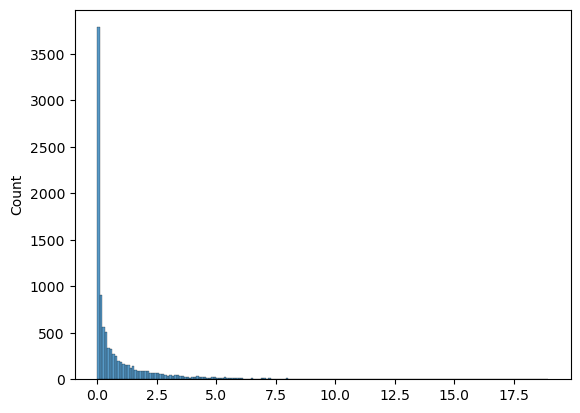

In [89]:
from scipy.stats import gamma

alpha_pred = prediction[0][0]
beta_pred = prediction[0][1]
print(f"alpha: {alpha_pred}, beta: {beta_pred}")

mean_pred = alpha_pred / beta_pred
var_pred = alpha_pred / pow(beta_pred, 2)
print(f"mean: {mean_pred}, variance: {var_pred}")

gamma = gamma.rvs(a = alpha_pred, scale = 1/beta_pred, size=10_000)
sns.histplot(gamma)

alpha: 0.25050604343414307, beta: 0.25141972303390503
mean: 0.9963659048080444, variance: 3.962958335876465


<Axes: ylabel='Count'>

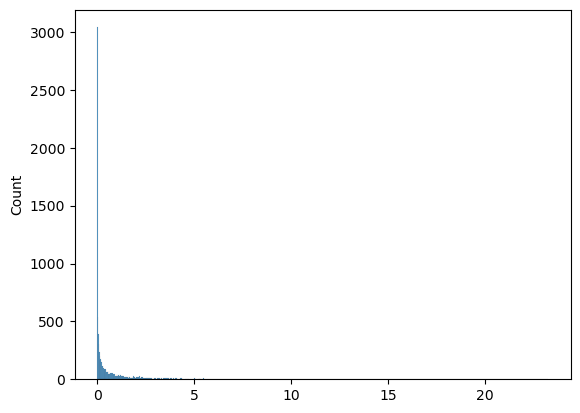

In [111]:
from scipy.stats import gamma

alpha_pred = prediction[0][0]
beta_pred = prediction[0][1]
print(f"alpha: {alpha_pred}, beta: {beta_pred}")

mean_pred = alpha_pred / beta_pred
var_pred = alpha_pred / pow(beta_pred, 2)
print(f"mean: {mean_pred}, variance: {var_pred}")

gamma = gamma.rvs(a = alpha_pred, scale = 1/beta_pred, size=10_000)
sns.histplot(gamma, bins=100000)

In [6]:
# 1.05/0.95
0.975/1.025
# 1.025/0.975

0.951219512195122

In [8]:
def sample_counts(N, freqs_T, S, seed = None):
    """
    Simulate sampled allele counts for all [generation, replicate] cells
    using the hypergeometric distribution.

    Parameters
    ----------
    N : int
        Diploid population size.
    freqs_T : np.ndarray
    Frequencies for all generations/replicates, shape (t+1, replicates).
    S : int
        Number of chromosomes sampled per cell.
    seed : int or None
        RNG seed.

    Returns
    -------
    numpy.ndarray
        Integer array of sampled A-allele counts, same shape as freqs_T.
    """
    rng = np.random.default_rng(seed)
    M = 2 * N
    K = np.rint(freqs_T * M).astype(int)  
    K = np.clip(K, 0, M)
    X = rng.hypergeometric(ngood = K, nbad = M - K, nsample = int(S))
    return X

In [6]:
dfL = df[['position', 'gen_10', 'gen_20', 'gen_30', 'gen_40', 'gen_50', 'gen_60']].copy()

# take 10,000 random positions
rng = np.random.default_rng(53)
randomPositions = rng.choice(
    dfL['position'].unique(),
    size=10_000,
    replace=False
)

# filter to only those random 10,000 positions
dfL = dfL[dfL.position.isin(randomPositions)]
dfL = dfL.melt(id_vars=['position'], var_name='gen', value_name='freq')
dfL

,position,gen,freq
0,4227,gen_10,0.000000
1,10322,gen_10,0.232323
2,29360,gen_10,0.181818
3,50746,gen_10,0.240741
4,63756,gen_10,0.821429
...,...,...,...
59995,21042987,gen_60,0.025210
59996,21066312,gen_60,0.187500
59997,21096084,gen_60,0.015544
59998,21105196,gen_60,0.034286


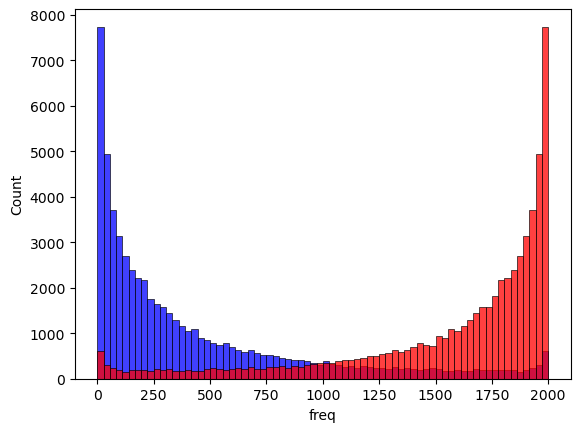

<Axes: ylabel='Count'>

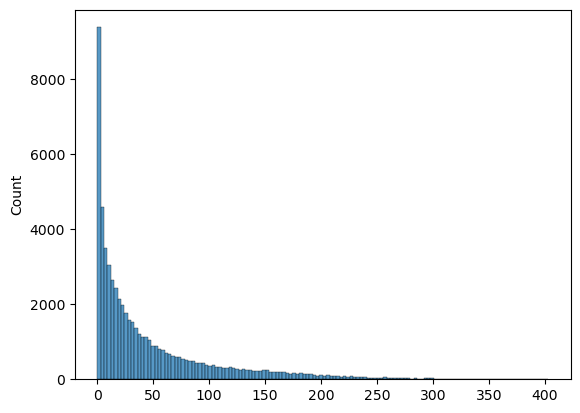

In [9]:
# sns.histplot(sample_counts(len(dfL.freq), dfL.freq, S=10_000, seed=42))
# sns.histplot(sample_counts(1, dfL.freq[1], S=1, seed=42))

X = np.rint(dfL.freq * 2000).astype(int)
X = np.clip(X, 0, 2000)
sns.histplot(X, color='blue')
sns.histplot(2000-X, color='red')
plt.show()

hypergeom = rng.hypergeometric(ngood=X, nbad=2000-X, nsample=tmp.value)
# hypergeom
sns.histplot(hypergeom)

<Axes: xlabel='value', ylabel='Count'>

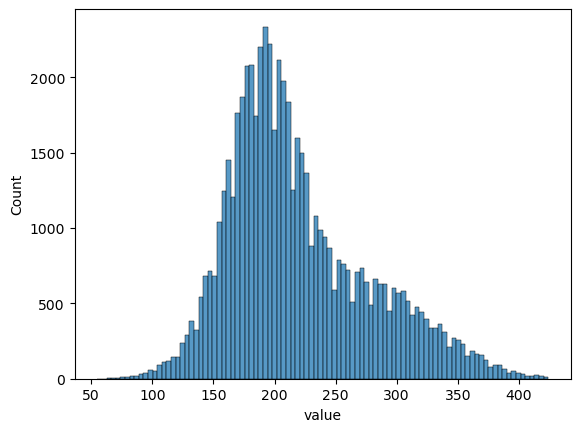

In [8]:
tmp = df[['position','total_gen_0','total_gen_20','total_gen_30','total_gen_40','total_gen_50','total_gen_60']]
tmp = tmp[tmp.position.isin(randomPositions)]
tmp = tmp.melt(id_vars=['position'])
sns.histplot(tmp.value)

In [20]:
def hypergeometric_sampling(N, freqs_T, S = None, seed = None):
    """ 
    Sample allele counts without replacement at each [generation, replicate]
    using a hypergeometric draw, then convert to sampled frequencies.

    Parameters
    ----------
    N : int
        Diploid population size (defines population copies M = 2N).
    freqs_T : np.ndarray
        True frequencies with shape (t+1, replicates)  [rows = generations, columns = replicates].
    S : int or None
        Sample size (number of chromosomes sampled). 
        If None: S = int(0.2 * N)
    seed : int or None
        RNG seed.

    Returns
    -------
    freqs_sampled_T : np.ndarray
        Sampled frequencies with same shape as freqs_T.
    """
    rng = np.random.default_rng(seed)
    M = 2 * N

    if S is None:
        S = int(0.2 * N)
    S = int(max(1, min(S, M)))  # clamp to [1, 2N]

    # convert true frequencies to integer counts in [0, M]
    K = np.rint(freqs_T * M).astype(int)  
    K = np.clip(K, 0, M) 

    # X ~ Hypergeom(ngood = K, nbad = M-K, nsample = S)
    X = rng.hypergeometric(ngood = K, nbad = M - K, nsample = S)

    freqs_sampled_T = X / S
    return freqs_sampled_T    

<Axes: ylabel='Count'>

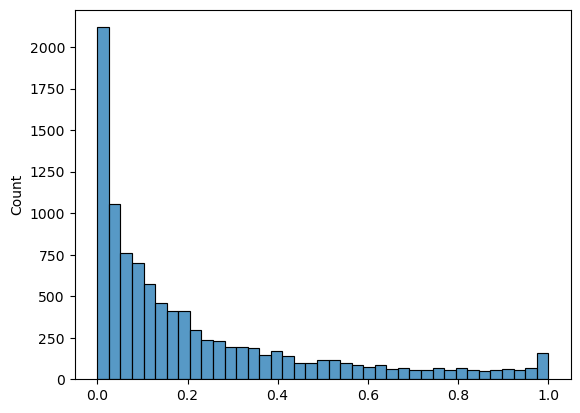

In [44]:
sns.histplot(hypergeometric_sampling(1_000, dfL.gen_10))

In [44]:
import numpy as np
import subprocess
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

def readAlleleFrequencyData(file_path="../data/chromosome_2L.sync"):
    columns = [
        'chromosome',
        'position',
        'base',
        'Dsim_Fl_Base_1',
        'Dsim_Fl_Hot_F10_1',
        'Dsim_Fl_Hot_F20_1', 
        'Dsim_Fl_Hot_F30_1',
        'Dsim_Fl_Hot_F40_1', 
        'Dsim_Fl_Hot_F50_1', 
        'Dsim_Fl_Hot_F60_1'
    ]

    df = pd.read_csv(
        filepath_or_buffer=file_path,
        sep='\t', # tab-separated values
        names=columns,
        usecols=columns,
        header=None # no headers provided
    )

    rename_dict = {
        'Dsim_Fl_Base_1':    'gen_0',
        'Dsim_Fl_Hot_F10_1': 'gen_10',
        'Dsim_Fl_Hot_F20_1': 'gen_20',
        'Dsim_Fl_Hot_F30_1': 'gen_30',
        'Dsim_Fl_Hot_F40_1': 'gen_40',
        'Dsim_Fl_Hot_F50_1': 'gen_50',
        'Dsim_Fl_Hot_F60_1': 'gen_60'
    }

    # Rename the columns (inplace=True modifies the original DataFrame)
    df.drop(columns=['chromosome'], inplace=True)
    df.rename(columns=rename_dict, inplace=True)

    rng = np.random.default_rng(53)
    randomPositions = rng.choice(
        df['position'].unique(),
        size=10_000,
        replace=False
    )
    df = df[df['position'].isin(randomPositions)]

    for column in ['gen_0','gen_10','gen_20','gen_30','gen_40','gen_50','gen_60']:
        df[[column, f'total_{column}']] = [
            alleleFrequency(b, c) 
            for b, c in zip(df['base'], df[column])
        ]
        
    for generation in [10,20,30,40,50,60]:
        prev_generation = generation - 10
        df[f'delta_{generation}'] = df[f'gen_{generation}'] - df[f'gen_{prev_generation}']

    return df;

Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [45]:
df = readAlleleFrequencyData()

In [94]:
def simulateTotals(df, seed=42):
    simTotals = pd.DataFrame()
    for gen in [10, 20, 30, 40, 50, 60]:
        actuals = df[f'gen_{gen}'] * 2000
        totals = df[f'total_gen_{gen}']

        rng = np.random.default_rng(seed)
        simTotals[f't{gen}'] = rng.hypergeometric(
            ngood=actuals,
            nbad=2000-actuals,
            nsample=totals
        )
    return simTotals;

sims = simulateTotals(df)
sims

,t10,t20,t30,t40,t50,t60
0,19,31,19,32,20,16
1,23,34,24,37,26,19
2,29,41,31,46,26,31
3,9,12,9,18,5,13
4,12,14,13,19,15,19
...,...,...,...,...,...,...
1068821,1,0,0,5,1,2
1068822,0,0,0,2,0,0
1068823,42,39,43,49,26,37
1068824,10,14,16,10,6,9


In [41]:
def hypergeometric_sample(seed=42):
    freqs, totals = readAlleleFrequencyData()
    freqs_scaled = freqs * 2000
    rng = np.random.default_rng(seed)
    distribution = rng.hypergeometric(ngood=freqs_scaled, nbad=2000-freqs_scaled, nsample=totals)
    return distribution;

<Axes: ylabel='Count'>

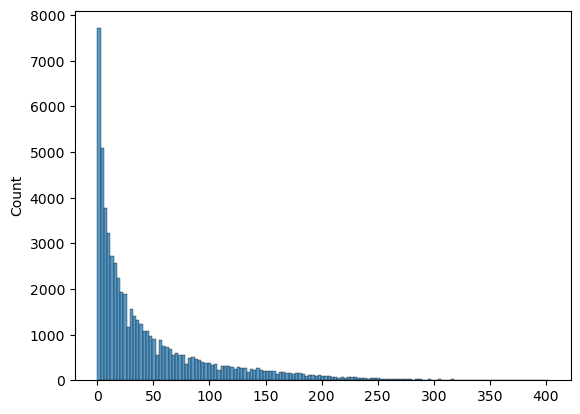

In [43]:
sns.histplot(hypergeometric_sample())

In [106]:
def singleHypergeometricSample(num_mutations, actual_total=401, seed=42):
    rng = np.random.default_rng(seed=seed)
    num_non_mutations = 2000 - num_mutations
    return rng.hypergeometric(size=len(num_mutations), ngood=num_mutations, nbad=num_non_mutations, nsample=actual_total)

# singleHypergeometricSample(num_mutations=[689], actual_total=401)

In [111]:
D = sim[['position', 'alpha', 'beta', 'sim_10', 'sim_20', 'sim_30', 'sim_40', 'sim_50', 'sim_60']]

for t in [10, 20, 30, 40, 50, 60]:
    # D[f'sim_{t}'] = singleHypergeometricSample(num_mutations=X[f'sim_{t}'])
    D.loc[:, f'sim_{t}'] = singleHypergeometricSample(num_mutations=X[f'sim_{t}'])

D

,position,alpha,beta,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60
0,10194546,2.975000,2.925000,4.0,7.0,7.0,6.0,6.0,5.0
1,10194549,2.975000,2.925000,7.0,7.0,7.0,8.0,6.0,6.0
2,10194552,2.975000,2.925000,6.0,4.0,11.0,8.0,7.0,10.0
3,10194557,2.975000,2.925000,0.0,0.0,0.0,0.0,0.0,0.0
4,10194670,2.975000,2.925000,14.0,16.0,17.0,19.0,19.0,19.0
...,...,...,...,...,...,...,...,...,...
2529995,12509860,1.002778,1.013889,2.0,1.0,0.0,2.0,0.0,4.0
2529996,12509995,1.002778,1.013889,0.0,0.0,0.0,0.0,0.0,0.0
2529997,12510001,1.002778,1.013889,1.0,0.0,2.0,1.0,6.0,2.0
2529998,12510011,1.002778,1.013889,1.0,2.0,2.0,1.0,3.0,1.0


In [109]:
sim

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
0,10194546,125.66925,195.12125,178.5000,175.37625,159.12750,149.26275,69.45200,-16.62125,-3.12375,-16.24875,-9.86475,2.975000,2.925000
1,10194549,135.48500,139.52125,139.6875,163.13625,117.78375,115.54650,4.03625,0.16625,23.44875,-45.35250,-2.23725,2.975000,2.925000
2,10194552,105.48475,127.88000,195.5625,132.91875,122.92875,187.53525,22.39525,67.68250,-62.64375,-9.99000,64.60650,2.975000,2.925000
3,10194557,5.39175,2.43250,0.0000,4.39875,4.04250,3.09825,-2.95925,-2.43250,4.39875,-0.35625,-0.94425,2.975000,2.925000
4,10194670,342.58350,461.82750,479.4375,466.65000,482.52750,469.65825,119.24400,17.61000,-12.78750,15.87750,-12.86925,2.975000,2.925000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529995,12509860,38.64350,34.79000,36.6240,61.50025,68.98375,86.17450,-3.85350,1.83400,24.87625,7.48350,17.19075,1.002778,1.013889
2529996,12509995,3.09575,0.00000,5.3760,6.52575,12.11000,0.00000,-3.09575,5.37600,1.14975,5.58425,-12.11000,1.002778,1.013889
2529997,12510001,24.23225,23.99800,44.0160,55.17225,48.87250,35.94325,-0.23425,20.01800,11.15625,-6.29975,-12.92925,1.002778,1.013889
2529998,12510011,19.32175,32.94400,49.0560,37.77025,40.43875,47.99875,13.62225,16.11200,-11.28575,2.66850,7.56000,1.002778,1.013889
